<a href="https://colab.research.google.com/github/Sneha8126/Python-Assignment/blob/main/Assignmnet_on_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DataSetForpython/taxi_trip_pricing.csv')

In [ ]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [ ]:
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [ ]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [ ]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [ ]:
df.shape

(1000, 11)

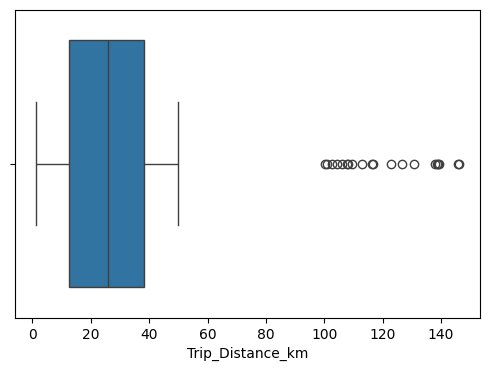

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Trip_Distance_km'])
plt.show()

In [ ]:
df.dropna(subset=['Trip_Price'], inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if col != 'Trip_Price':   # Don't touch the target column
        df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print(df.isnull().sum())

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


In [ ]:
df.shape

(951, 11)

In [ ]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,25.87,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028


In [ ]:
df['Time_of_Day'].value_counts()

,count
Time_of_Day,
Afternoon,400
Morning,265
Evening,197
Night,89


In [ ]:
df['Day_of_Week'].value_counts()

,count
Day_of_Week,
Weekday,668
Weekend,283


In [ ]:
df['Traffic_Conditions'].value_counts()

,count
Traffic_Conditions,
Low,424
Medium,355
High,172


In [ ]:
df['Weather'].value_counts()

,count
Weather,
Clear,680
Rain,216
Snow,55


In [ ]:
traffic_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
df['Traffic_Conditions'] = df['Traffic_Conditions'].map(traffic_map)

In [ ]:
df = pd.get_dummies(df, columns=['Weather'], drop_first=True)

In [ ]:
time_map = {
    'Morning': 0,
    'Afternoon': 1,
    'Evening': 2,
    'Night': 3
}
df['Time_of_Day'] = df['Time_of_Day'].map(time_map)

In [ ]:
day_map = {
    'Weekday': 0,
    'Weekend': 1
}

df['Day_of_Week'] = df['Day_of_Week'].map(day_map)

In [ ]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Weather_Rain,Weather_Snow
0,19.35,0,0,3.0,0,3.56,0.80,0.32,53.82,36.2624,False,False
2,36.87,2,1,1.0,2,2.70,1.21,0.15,37.27,52.9032,False,False
3,30.33,2,0,4.0,0,3.48,0.51,0.15,116.81,36.4698,False,False
4,25.87,2,0,3.0,2,2.93,0.63,0.32,22.64,15.6180,False,False
5,8.64,1,1,2.0,1,2.55,1.71,0.48,89.33,60.2028,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       951 non-null    float64
 1   Time_of_Day            951 non-null    int64  
 2   Day_of_Week            951 non-null    int64  
 3   Passenger_Count        951 non-null    float64
 4   Traffic_Conditions     951 non-null    int64  
 5   Base_Fare              951 non-null    float64
 6   Per_Km_Rate            951 non-null    float64
 7   Per_Minute_Rate        951 non-null    float64
 8   Trip_Duration_Minutes  951 non-null    float64
 9   Trip_Price             951 non-null    float64
 10  Weather_Rain           951 non-null    bool   
 11  Weather_Snow           951 non-null    bool   
dtypes: bool(2), float64(7), int64(3)
memory usage: 83.6 KB


In [ ]:
int_col = df.describe().columns
int_col

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate',
       'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [ ]:
int_df = df[int_col]
int_df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,0,0,3.0,0,3.56,0.80,0.32,53.82,36.2624
2,36.87,2,1,1.0,2,2.70,1.21,0.15,37.27,52.9032
3,30.33,2,0,4.0,0,3.48,0.51,0.15,116.81,36.4698
4,25.87,2,0,3.0,2,2.93,0.63,0.32,22.64,15.6180
5,8.64,1,1,2.0,1,2.55,1.71,0.48,89.33,60.2028


<Axes: >

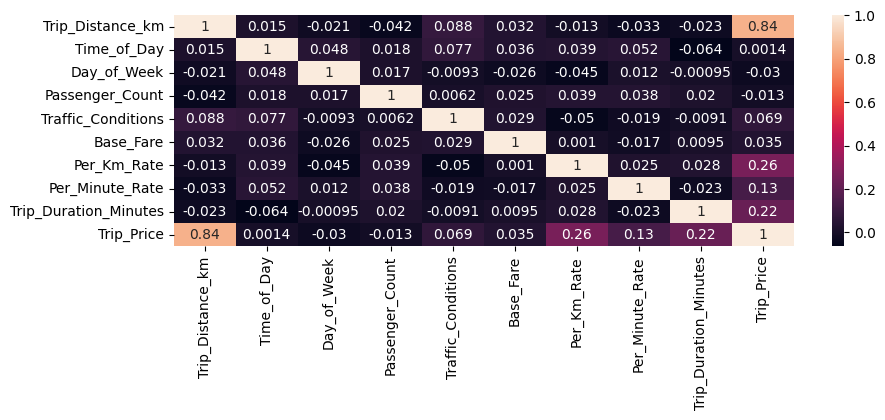

In [ ]:
plt.figure(figsize=(10,3))
sns.heatmap(int_df.corr(),annot=True)

In [ ]:
x = df.drop('Trip_Price',axis = 1)
y = df['Trip_Price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(760, 11)

In [ ]:
x_test.shape

(191, 11)

In [ ]:
y_train.shape

(760,)

In [ ]:
y_test.shape

(191,)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([ 1.70969614, -0.71244664, -0.05942153, -0.17924941,  0.61612608,
       -0.0587712 , 24.88804769, 54.67332423,  0.30163907, -0.99632378,
        2.18773431])

In [ ]:
train_pred = model.predict(x_train)
train_pred[:5]

array([ 77.26354096,  82.83297323,  57.15209254, 108.74092952,
        90.71943492])

In [ ]:
y_train.head().values

array([ 73.5818,  72.9188,  65.6944, 106.0042,  87.6076])

In [ ]:
test_pred = model.predict(x_test)
test_pred[:5]

array([ 44.43140245, 106.76983933,   1.47790219,  45.87576957,
        67.38567838])

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
print('Train Mean Squared Error :-',mean_squared_error(y_train,train_pred))
print('Train Root Mean Squared Error :-',np.sqrt(mean_squared_error(y_train,train_pred)))
print('Train Mean Absolute Error :-',mean_absolute_error(y_train,train_pred))
print('Train Mean Absolute Percentage Error :-',mean_absolute_percentage_error(y_train,train_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train Mean Squared Error :- 207.9185535193384
Train Root Mean Squared Error :- 14.419381176712765
Train Mean Absolute Error :- 9.31891263598585
Train Mean Absolute Percentage Error :- 0.2433849313023687
Train R2 Score :- 0.857228562453173


In [ ]:
print('Test Mean Squared Error :-',mean_absolute_error(y_test,test_pred))
print('Test Root Mean Squared Error :-',np.sqrt(mean_squared_error(y_test,test_pred)))
print('Test Mean Absolute Error :-',mean_absolute_error(y_test,test_pred))
print('Test Mean Absolute Percentage Error :-',mean_absolute_percentage_error(y_test,test_pred))
print('Test R2 Score :-',r2_score(y_test,test_pred))

Test Mean Squared Error :- 9.841991298058234
Test Root Mean Squared Error :- 16.935844874320516
Test Mean Absolute Error :- 9.841991298058234
Test Mean Absolute Percentage Error :- 0.20724938666109574
Test R2 Score :- 0.8772886812964323
